# Credit Card Fraud Detection Task - NeuroNexus Assignment

### This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

### data description copied from kaggle

## Import Necessary Libraries and Checking Essential Data Aspects

In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_curve, auc
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

data = pd.read_csv("creditcard.csv")
data.sample(10)


 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
138510,82686.0,1.299821,-0.158950,-0.864808,-0.526540,1.817745,3.449813,-0.797331,0.880622,0.169629,...,-0.046085,-0.241445,-0.035908,1.033435,0.497769,0.362348,-0.013063,0.012772,2.46,0
88497,62166.0,-3.019038,-0.231095,0.502540,1.229441,1.530924,0.685525,-1.803856,-1.715394,-0.683232,...,2.131220,-0.906694,-1.183669,-1.241198,-0.166367,-0.237934,0.773743,-0.672334,3.99,0
223192,143282.0,1.721481,-0.606310,-3.403267,-0.460617,2.550883,3.051316,-0.155540,0.681258,0.416309,...,0.288259,0.508986,-0.129152,0.636502,0.228310,-0.098213,-0.013594,-0.006504,170.00,0
111900,72420.0,-0.429524,0.221470,-0.008404,-1.945732,2.219199,3.545041,0.218529,0.932643,-0.002295,...,-0.231640,-0.802961,0.078344,1.034475,-0.387246,0.608816,0.039698,0.133074,53.24,0
203176,134694.0,1.886187,-0.562020,-1.928928,-1.046098,0.718363,0.325691,0.093122,0.081077,0.524771,...,0.206393,0.762165,0.074092,-1.253761,-0.134161,0.839555,-0.062873,-0.094646,50.00,0
116760,74417.0,-3.264725,-1.448711,0.379446,-3.238987,-1.111209,-1.386119,-0.166418,0.453795,0.728579,...,-0.543377,-0.007973,0.698126,0.424570,0.092051,-0.408184,0.270928,-0.374358,116.81,0
210001,137800.0,-0.876927,0.052844,-0.372208,-1.288551,2.114224,-0.861621,1.790012,-0.355958,-0.533181,...,0.304543,0.619516,-0.249262,0.266511,0.769772,-0.557477,-0.164738,-0.106108,100.00,0
198658,132593.0,-5.224438,-0.150372,-1.646794,-2.718859,-0.351063,1.826985,1.081504,-2.575687,3.243104,...,0.923982,-0.258996,0.065374,-1.554724,-2.127576,-0.364644,-3.007720,-0.076810,281.86,0
86489,61256.0,-0.393519,0.575352,0.012149,-0.959281,2.347835,3.737540,-0.034536,1.017041,0.033604,...,-0.076404,-0.024963,-0.229489,1.056069,0.018932,0.378389,0.361870,0.193453,2.99,0
148394,89812.0,1.820494,-0.392960,-0.785468,1.504178,0.235447,1.049398,-0.401278,0.437178,1.395863,...,-0.275005,-0.364877,0.345852,-1.117536,-0.232066,-0.714765,0.080502,-0.059201,6.00,0


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### no null values , we are good to go and move forward

In [31]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


<Axes: xlabel='Class', ylabel='count'>

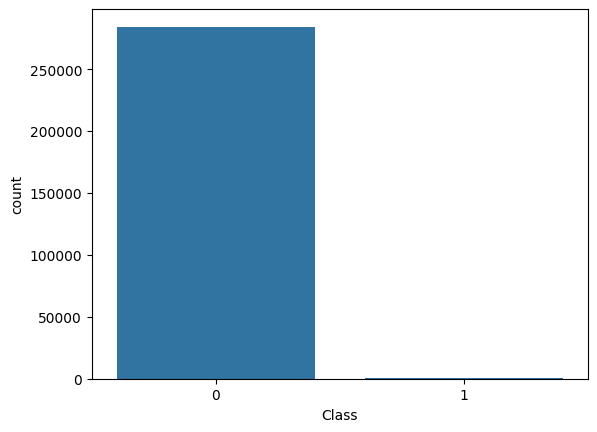

In [32]:
sns.countplot(data=data,x='Class') 

### as mentioned in the description of the assignment's data set we can see that there is a class imbalance in our data set , this will effect our model so we have to take care of this before training our model on this data set

### But first let us , Normalize the Transaction data as asked in the assignment , We will not touch the V1 to V28 because they are dimensions obtained after performing PCA as told in the description . Let us normalize/standardize the Amount column and the Time column . 

Note -> Even though the assignment mentions "normalization" , I am performing Standardization using the scaler as it shows better results with LogisticRegression and serves the purpose of scaling the values to range of [-1,1] centering the values to 0 and keeping the values on same scale

In [33]:
data_normalized = data.copy() # we don't want to disturb the original data


In [34]:
X = data_normalized.drop(columns=['Class'])
y = data_normalized['Class']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


In [35]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [36]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [37]:
scalar = StandardScaler() #we will be scaling the feature columns z = x-mean/std
X_train_scaled = scalar.fit_transform(X_train[['Amount','Time']])
X_test_scaled = scalar.transform(X_test[['Amount','Time']])
X_train_scaled_all = np.hstack((X_train.drop(columns=['Amount', 'Time']).values, X_train_scaled))
X_test_scaled_all = np.hstack((X_test.drop(columns=['Amount', 'Time']).values, X_test_scaled))

## Now that we have spliited and scaled the Amount and Time features we will now be handling the class imbalance issue . Let's use undersampling and oversampling , then compare the results on LogisticRegression , RandomForestClassifier

In [38]:
under_sampler = RandomUnderSampler()
smote = SMOTE()
X_train_undersampled,y_train_undersampled = under_sampler.fit_resample(X_train_scaled_all,y_train)
X_train_oversampled , y_train_oversampled = smote.fit_resample(X_train_scaled_all,y_train)

In [39]:
rf_under = RandomForestClassifier()
rf_over = RandomForestClassifier()
lr_under = LogisticRegression()
lr_over = LogisticRegression()

In [41]:
lr_over.fit(X_train_oversampled,y_train_oversampled)
y_preds_lr_over = lr_over.predict(X_test_scaled_all)
lr_under.fit(X_train_undersampled,y_train_undersampled)
y_preds_lr_under = lr_under.predict(X_test_scaled_all)

In [42]:
rf_over.fit(X_train_oversampled,y_train_oversampled)
y_preds_rf_over = rf_over.predict(X_test_scaled_all)
rf_under.fit(X_train_undersampled,y_train_undersampled)
y_preds_rf_under = rf_under.predict(X_test_scaled_all)

In [43]:
print(classification_report(y_test,y_preds_lr_over))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     71089
           1       0.05      0.93      0.10       113

    accuracy                           0.97     71202
   macro avg       0.53      0.95      0.54     71202
weighted avg       1.00      0.97      0.99     71202



In [44]:
print(classification_report(y_test,y_preds_lr_under))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     71089
           1       0.06      0.93      0.12       113

    accuracy                           0.98     71202
   macro avg       0.53      0.95      0.55     71202
weighted avg       1.00      0.98      0.99     71202



In [ ]:
print(classification_report(y_test,y_preds_rf_over))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     71089
           1       0.01      0.30      0.02       113

    accuracy                           0.95     71202
   macro avg       0.50      0.62      0.49     71202
weighted avg       1.00      0.95      0.97     71202



In [45]:
print(classification_report(y_test,y_preds_rf_under))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     71089
           1       0.07      0.91      0.14       113

    accuracy                           0.98     71202
   macro avg       0.54      0.95      0.56     71202
weighted avg       1.00      0.98      0.99     71202



### Precision (Class 1): Of all transactions predicted as fraud, how many were actually fraud.

### Recall (Class 1): Of all actual frauds, how many did the model successfully catch.

### F1-Score (Class 1): The balance between precision and recall — how well the model avoids both false alarms and missed frauds.

#### Let's tune hyperparameters of our randomforest with over-sampling as it has the best report/result

In [50]:
params_grid = {
    'n_estimators':[100,200],
    'min_samples_split':[2],
    'max_depth':[5,10,20],
    'oob_score':[False,True]
}

grid_search = GridSearchCV(estimator=rf_over,param_grid=params_grid,cv=5,verbose=2,n_jobs=-1,scoring='recall')

grid_search.fit(X_train_undersampled,y_train_undersampled)

print(f'Best estimator parameters:{grid_search.best_params_}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best estimator parameters:{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200, 'oob_score': True}


In [51]:
best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test_scaled_all)
print(classification_report(best_preds,y_test))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     69681
           1       0.91      0.07      0.13      1521

    accuracy                           0.98     71202
   macro avg       0.95      0.53      0.56     71202
weighted avg       0.98      0.98      0.97     71202



#### Threshold tuning with and without hyperparameter tuning

In [55]:
y_probs = best_rf.predict_proba(X_test_scaled_all)[:, 1]
y_preds_best = (y_probs > 0.5).astype(int)  
print(classification_report(y_preds_best,y_test))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     69681
           1       0.91      0.07      0.13      1521

    accuracy                           0.98     71202
   macro avg       0.95      0.53      0.56     71202
weighted avg       0.98      0.98      0.97     71202



In [ ]:
y_probs = rf_over.predict_proba(X_test_scaled_all)[:, 1]
y_preds = (y_probs > 0.3).astype(int)  

print(classification_report(y_preds,y_test))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71062
           1       0.88      0.71      0.79       140

    accuracy                           1.00     71202
   macro avg       0.94      0.86      0.90     71202
weighted avg       1.00      1.00      1.00     71202



## Based on our testing of the models , hyperparameter tuning and threshold tuning(using probabilities as thrsholds) we choose rf_over that is randomforest with oversampling which performed great and provided us a high recall and f1-score showing that it can effectively identify fraud. Moreover I choose to only to tune rf_over because it was the best performing model without tuning and was the only one making real predictions for fraud rather than just guessing "not fraud" or 0 every time 

d:\NeuroNexus-CreditCardFraud\venv\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


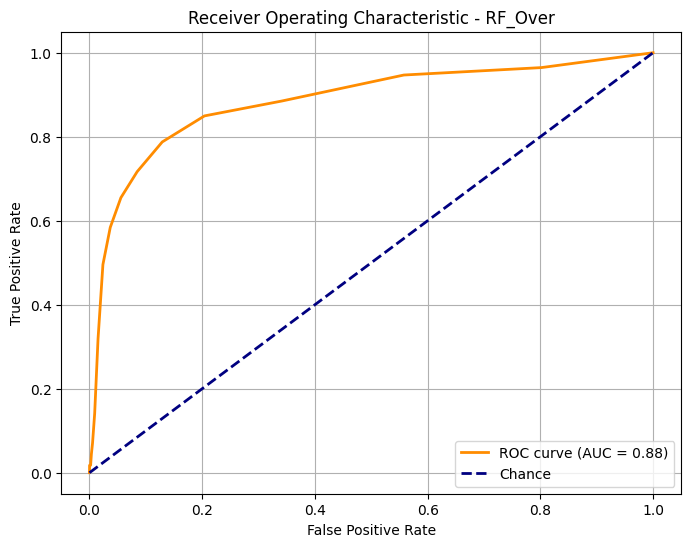

In [ ]:
## Let's visualize the performance of our rf_over with threshold tuning 


y_scores = rf_over.predict_proba(X_test)[:, 1]  

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - RF_Over')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
